Exercise 1: Duplicate Detection and Removal
Instructions
Objective: Identify and remove duplicate entries in the Titanic dataset.

Load the Titanic dataset.
Identify if there are any duplicate rows based on all columns.
Remove any duplicate rows found in the dataset.
Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.
Hint: Use the duplicated() and drop_duplicates() functions in Pandas.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load the dataset
df = pd.read_csv('train.csv')

# Display basic info
print(df.head())
print(df.info())
print(df.describe())

#This dataset is clean and there are no duplicates as seen in the output from below.
num_duplicates = df.duplicated().sum() 

print(f"Number of duplicate rows: {num_duplicates}")

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

xercise 2: Handling Missing Values
Instructions
Identify columns in the Titanic dataset with missing values.
Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
Apply each strategy to different columns based on the nature of the data.
Hint: Review methods like dropna(), fillna(), and SimpleImputer from scikit-learn.

In [12]:
#Checking for missing values with info visually, missing values found in age, cabin and embarked.
df.info()

df = pd.read_csv('train.csv')
# Dropping Cabin alltogether - too many missing values
df = df.drop('Cabin', axis=1)

# Assigned a median age in place of the missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
# Filling Embarked with mode (most common value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Exercise 3: Feature Engineering
Instructions
Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.
Hint: Utilize Pandas for data manipulation and scikit-learn’s preprocessing module for encoding.

In [13]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

def extract_title(name):
    return name.split(',')[1].split('.')[0].strip()

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Title'] = df['Name'].apply(extract_title)

title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Other')

encoder = OneHotEncoder(sparse_output=False, drop='first')

title_encoded = encoder.fit_transform(df[['Title']])
title_encoded_df = pd.DataFrame(title_encoded, columns=encoder.get_feature_names_out(['Title']))
df = pd.concat([df, title_encoded_df], axis=1)

sex_encoded = encoder.fit_transform(df[['Sex']])
sex_encoded_df = pd.DataFrame(sex_encoded, columns=encoder.get_feature_names_out(['Sex']))
df = pd.concat([df, sex_encoded_df], axis=1)

pclass_encoded = encoder.fit_transform(df[['Pclass']])
pclass_encoded_df = pd.DataFrame(pclass_encoded, columns=encoder.get_feature_names_out(['Pclass']))
df = pd.concat([df, pclass_encoded_df], axis=1)

print(df.head())
print(df.columns.tolist())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  FamilySize Title  Title_Miss  \
0      0         A/5 21171   7.2500        S           2    Mr         0.0   
1      0          PC 17599  71.2833        C           2   Mrs         0.0   
2      0  STON/O2. 3101282   7.9250        S           1  Miss         1.0   
3      0

Exercise 4: Outlier Detection and Handling
Goal: Detect and cap or transform outliers in columns like Fare and Age.

Visualize distributions using boxplots or histograms to identify potential outliers.
Use IQR or Z-score methods to detect them.
Handle outliers with:

Quantile capping (e.g. 0.98)
Log transformation
Row removal
Compare the dataset before and after treatment.

Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.

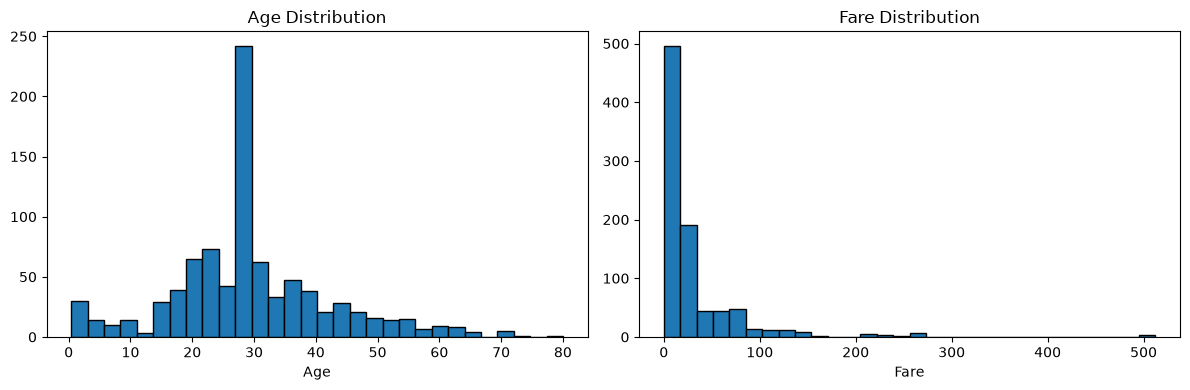

Age outliers (IQR): 66
Age bounds: 2.5 to 54.5
Fare outliers (IQR): 116
Fare bounds: -26.724 to 65.6344
Age 98th percentile: 62.0
Fare 98th percentile: 211.3375
Age max after capping: 62.0
Fare max after capping: 211.3375


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# NOTE: do NOT reload train.csv here - that would discard the cleaning from
# Exercise 2 and the FamilySize / Title / one-hot columns from Exercise 3.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Age'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[1].hist(df['Fare'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')
plt.tight_layout()
plt.show()
def detect_outliers_iqr(data, column, multiplier=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound
age_outliers, age_lower, age_upper = detect_outliers_iqr(df, 'Age')
fare_outliers, fare_lower, fare_upper = detect_outliers_iqr(df, 'Fare')
print("Age outliers (IQR): " + str(len(age_outliers)))
print("Age bounds: " + str(age_lower) + " to " + str(age_upper))
print("Fare outliers (IQR): " + str(len(fare_outliers)))
print("Fare bounds: " + str(fare_lower) + " to " + str(fare_upper))
age_98 = df['Age'].quantile(0.98)
fare_98 = df['Fare'].quantile(0.98)
df['Age'] = df['Age'].clip(upper=age_98)
df['Fare'] = df['Fare'].clip(upper=fare_98)
print("Age 98th percentile: " + str(age_98))
print("Fare 98th percentile: " + str(fare_98))
print("Age max after capping: " + str(df['Age'].max()))
print("Fare max after capping: " + str(df['Fare'].max()))

Exercise 5: Data Standardization and Normalization
Goal: Scale numerical features to prepare for modeling.

Use StandardScaler (mean = 0, std = 1) for normally distributed features.
Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.
mportant: Perform this step after outlier treatment to avoid distortion caused by extreme values.

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

numerical_features = ['Age', 'Fare', 'FamilySize']

# Keep the age in years before scaling - Exercise 7 needs it to build the
# life-stage bins, which are defined on the original scale.
df['Age_years'] = df['Age']

scaler_std = StandardScaler()
df[['Age', 'FamilySize']] = scaler_std.fit_transform(df[['Age', 'FamilySize']])

scaler_minmax = MinMaxScaler()
df[['Fare']] = scaler_minmax.fit_transform(df[['Fare']])

print(df[numerical_features].describe())

                Age        Fare    FamilySize
count  8.910000e+02  891.000000  8.910000e+02
mean   1.674680e-16    0.145163 -2.392400e-17
std    1.000562e+00    0.188821  1.000562e+00
min   -2.268481e+00    0.000000 -5.609748e-01
25%   -5.709877e-01    0.037430 -5.609748e-01
50%   -9.902481e-02    0.068394 -5.609748e-01
75%    4.515986e-01    0.146685  5.915988e-02
max    2.575432e+00    1.000000  5.640372e+00


Exercise 6: Feature Encoding
Goal: Finalize categorical variable encoding.

Identify remaining categorical columns (e.g. Sex, Embarked, Title).
Apply:

One-Hot Encoding for nominal variables.
Label Encoding if any ordinal variables remain.
Merge encoded columns back into the main dataset.

Reminder: Encoding comes after handling missing values and outliers, but before scaling (if applicable).



In [16]:
embarked_encoded = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)
df = pd.concat([df, embarked_encoded], axis=1)

columns_to_drop = ['Name', 'Sex', 'Title', 'Embarked', 'Ticket', 'PassengerId']
df = df.drop(columns=columns_to_drop)

print(df.columns.tolist())
print(df.dtypes)
print(df.head())

print(df.columns.tolist())

df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

print(df.dtypes)
print(df.head())

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Other', 'Sex_male', 'Pclass_2', 'Pclass_3', 'Age_years', 'Embarked_Q', 'Embarked_S']
Survived         int64
Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
FamilySize     float64
Title_Miss     float64
Title_Mr       float64
Title_Mrs      float64
Title_Other    float64
Sex_male       float64
Pclass_2       float64
Pclass_3       float64
Age_years      float64
Embarked_Q        bool
Embarked_S        bool
dtype: object
   Survived  Pclass       Age  SibSp  Parch      Fare  FamilySize  Title_Miss  \
0         0       3 -0.570988      1      0  0.034305    0.059160         0.0   
1         1       1  0.687580      1      0  0.337296    0.059160         0.0   
2         1       3 -0.256346      0      0  0.037499   -0.560975         1.0   
3         1       1  0.451599      1      0  0.251257    0.059160     

Exercise 7: Data Transformation for Age Feature
Goal: Create and encode age groups.

Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
Apply one-hot encoding using pd.get_dummies().
Example: You might define bins like [0, 12, 18, 60, 100] and label them accordingly.

In [17]:
# Bin on Age_years (the pre-scaling age saved in Exercise 5), not on the
# standardized Age - the bin edges below are in years.
df['AgeGroup'] = pd.cut(df['Age_years'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'], right=False)

print(df['AgeGroup'].value_counts().sort_index())

agegroup_encoded = pd.get_dummies(df['AgeGroup'], prefix='AgeGroup', drop_first=True)
df = pd.concat([df, agegroup_encoded], axis=1)

# AgeGroup and the helper column have done their job
df = df.drop(columns=['AgeGroup', 'Age_years'])

df['AgeGroup_Teen'] = df['AgeGroup_Teen'].astype(int)
df['AgeGroup_Adult'] = df['AgeGroup_Adult'].astype(int)
df['AgeGroup_Senior'] = df['AgeGroup_Senior'].astype(int)

print(df.dtypes)
print(df.head())

AgeGroup
Child      68
Teen       45
Adult     752
Senior     26
Name: count, dtype: int64
Survived             int64
Pclass               int64
Age                float64
SibSp                int64
Parch                int64
Fare               float64
FamilySize         float64
Title_Miss         float64
Title_Mr           float64
Title_Mrs          float64
Title_Other        float64
Sex_male           float64
Pclass_2           float64
Pclass_3           float64
Embarked_Q           int64
Embarked_S           int64
AgeGroup_Teen        int64
AgeGroup_Adult       int64
AgeGroup_Senior      int64
dtype: object
   Survived  Pclass       Age  SibSp  Parch      Fare  FamilySize  Title_Miss  \
0         0       3 -0.570988      1      0  0.034305    0.059160         0.0   
1         1       1  0.687580      1      0  0.337296    0.059160         0.0   
2         1       3 -0.256346      0      0  0.037499   -0.560975         1.0   
3         1       1  0.451599      1      0  0.251257    0